In [32]:
import numpy as np
import struct
from collections import defaultdict
import heapq
import time
from tqdm.auto import tqdm
from sklearn.neighbors import NearestNeighbors

class SupervisedHubsHNSW:
    def __init__(self, base_vectors, hub_levels=4, max_connections=16, ef_construction=400):
        self.base = base_vectors.astype(np.float32)
        self.base_norms = np.sum(self.base ** 2, axis=1).astype(np.float32)  # Precompute squared norms
        self.max_level = hub_levels
        self.M = max_connections
        self.efc = ef_construction
        self.entry_point = None
        self.hierarchy = [defaultdict(list) for _ in range(hub_levels)]  # Store as lists initially
        self.hub_scores = np.zeros(len(base_vectors), dtype=np.float32)
        self.layer_nodes = []

    def learn_hierarchy(self, learn_ground_truth):
        """Vectorized hub score calculation"""
        processed_gt = []
        for neighbors in tqdm(learn_ground_truth, desc="Processing GT"):
            valid_neighbors = []
            for idx in neighbors:
                adj_idx = idx - 1 if idx > 0 else idx
                if 0 <= adj_idx < len(self.base):
                    valid_neighbors.append(adj_idx)
            processed_gt.append(valid_neighbors[:100])

        decay_rate = 2.0
        max_neighbors = max(len(n) for n in processed_gt) if processed_gt else 0
        decay_values = np.exp(-np.arange(max_neighbors) / decay_rate)

        for neighbors in tqdm(processed_gt, desc="Learning hubs"):
            if not neighbors:
                continue
            indices = np.array(neighbors, dtype=np.int32)
            valid_indices = indices[indices < len(self.hub_scores)]  # Ensure indices are within bounds
            n = len(valid_indices)
            if n == 0:
                continue
            values = decay_values[:n]
            np.add.at(self.hub_scores, valid_indices, values)

    def build_index(self):
        self.layer_nodes = [np.arange(len(self.base))]
        for level in range(1, self.max_level):
            prev_layer = self.layer_nodes[level-1]
            sorted_nodes = prev_layer[np.argsort(-self.hub_scores[prev_layer])]
            self.layer_nodes.append(sorted_nodes[:len(sorted_nodes)//2])
        
        for level in range(self.max_level):
            self.construct_level(level)
            # Convert neighbor lists to numpy arrays for faster access
            for node in self.hierarchy[level]:
                unique_conns = list(set(self.hierarchy[level][node]))  # Deduplicate
                self.hierarchy[level][node] = np.array(unique_conns, dtype=np.int32)
        
        self.entry_point = self.layer_nodes[-1][np.argmax(self.hub_scores[self.layer_nodes[-1]])]

    def construct_level(self, level):
        layer_nodes = self.layer_nodes[level]
        if len(layer_nodes) == 0:
            return
        
        sorted_nodes = layer_nodes[np.argsort(-self.hub_scores[layer_nodes])]
        level_hubs = sorted_nodes[:int(len(layer_nodes)*0.1)]
        if len(level_hubs) == 0:
            return
        
        hub_vecs = self.base[level_hubs]
        layer_vecs = self.base[layer_nodes]

        # Vectorized distance calculation
        dot_product = layer_vecs @ hub_vecs.T
        sum_squares_layer = np.sum(layer_vecs**2, axis=1, keepdims=True)
        sum_squares_hub = np.sum(hub_vecs**2, axis=1)
        dists = sum_squares_layer + sum_squares_hub - 2 * dot_product

        # Find nearest M hubs for each node
        nearest_indices = np.argpartition(dists, self.M, axis=1)[:, :self.M]
        connections_for_all = level_hubs[nearest_indices]

        # Build connections
        for i in tqdm(range(len(layer_nodes)), desc=f"Building L{level}"):
            node_idx = layer_nodes[i]
            connections = connections_for_all[i].tolist()
            # Forward connections
            self.hierarchy[level][node_idx].extend(connections)
            # Reverse connections
            for conn in connections:
                if node_idx not in self.hierarchy[level][conn]:
                    self.hierarchy[level][conn].append(node_idx)

    def search_level(self, query, k, level, entry=None, ef_search=100):
        candidates = []
        visited = set()
        layer_nodes = set(self.layer_nodes[level])
        query_norm = np.sum(query ** 2)

        if entry is None:
            entry = self.layer_nodes[level][np.argmax(self.hub_scores[self.layer_nodes[level]])]
        entry_norm = self.base_norms[entry]
        initial_dist_sq = query_norm + entry_norm - 2 * np.dot(query, self.base[entry])
        heapq.heappush(candidates, (initial_dist_sq, entry))

        results = []
        count_visited = 0
        while candidates and count_visited <= ef_search:
            current_dist_sq, node = heapq.heappop(candidates)
            if node not in layer_nodes or node in visited:
                continue
            visited.add(node)
            count_visited += 1

            if count_visited > ef_search:
                break

            heapq.heappush(results, (-current_dist_sq, node))
            if len(results) > k:
                heapq.heappop(results)

            # Iterate through numpy array for neighbors
            for neighbor in self.hierarchy[level].get(node, np.array([], dtype=np.int32)):
                if neighbor in visited or neighbor not in layer_nodes:
                    continue
                neighbor_norm = self.base_norms[neighbor]
                neighbor_dist_sq = query_norm + neighbor_norm - 2 * np.dot(query, self.base[neighbor])
                heapq.heappush(candidates, (neighbor_dist_sq, neighbor))

        return [n for _, n in sorted(results, reverse=True)]

    def query(self, query, k=10, ef=200):
        query = query.astype(np.float32)
        results = []
        entry = None
        query_norm = np.sum(query ** 2)

        for level in reversed(range(self.max_level)):
            level_results = self.search_level(query, k, level, entry=entry, ef_search=ef)
            entry = level_results[0] if level_results else None
            combined = list(set(results + level_results))
            # Sort by squared distance using precomputed norms
            combined_dists = {x: query_norm + self.base_norms[x] - 2 * np.dot(query, self.base[x]) for x in combined}
            results = sorted(combined, key=lambda x: combined_dists[x])[:k]

        return results[:k]

    # evaluate and data loading functions remain unchanged
    def evaluate(self, queries, ground_truth, k=10):
        recall_at_1 = []
        recall_at_k = []
        latencies = []
        
        for q, gt in tqdm(zip(queries, ground_truth), desc="Evaluating"):
            start = time.perf_counter()
            pred = self.query(q, k=k, ef=self.efc)
            latencies.append(time.perf_counter() - start)
            
            valid_gt = set(int(idx) for idx in gt if 0 <= int(idx) < len(self.base))
            valid_pred = pred[:k]
            
            recall_1 = 1.0 if valid_pred[0] in valid_gt else 0.0
            recall_at_1.append(recall_1)
            
            correct = sum(1 for p in valid_pred if p in valid_gt)
            recall_at_k.append(correct / k)
        
        return {
            'recall@1': np.mean(recall_at_1),
            'recall@10': np.mean(recall_at_k),
            'latency_mean': np.mean(latencies) * 1000,
            'latency_p95': np.percentile(latencies, 95) * 1000
        }
# Data loading functions remain unchanged
def read_fvecs(fp):
    with open(fp, 'rb') as f:
        vecs = []
        while True:
            header = f.read(4)
            if not header: break
            dim = struct.unpack('i', header)[0]
            vec = struct.unpack('f'*dim, f.read(4*dim))
            vecs.append(np.array(vec))
    return np.vstack(vecs).astype(np.float32)

def read_ivecs(fp):
    with open(fp, 'rb') as f:
        vecs = []
        while True:
            header = f.read(4)
            if not header: break
            dim = struct.unpack('i', header)[0]
            vec = struct.unpack('i'*dim, f.read(4*dim))
            vecs.append(np.array(vec))
    return np.vstack(vecs)
if __name__ == "__main__":
    # Load data
    base = read_fvecs('./siftsmall/siftsmall_base.fvecs')
    ground_truth = read_ivecs('./siftsmall/siftsmall_groundtruth.ivecs')
    queries = read_fvecs('./siftsmall/siftsmall_query.fvecs')

    # Normalize
    base_norm = base / np.linalg.norm(base, axis=1, keepdims=True)
    queries_norm = queries / np.linalg.norm(queries, axis=1, keepdims=True)

    # Create and train index
    index = SupervisedHubsHNSW(base_norm, hub_levels=3, max_connections=8, ef_construction=30)
    index.learn_hierarchy(ground_truth)
    index.build_index()

    # Evaluate
    metrics = index.evaluate(queries_norm, ground_truth)
    print(f"Recall@10: {metrics['recall@10']:.3f}")
    print(f"Latency: {metrics['latency_mean']:.1f}ms ± {metrics['latency_p95']:.1f}ms")

Processing GT:   0%|          | 0/100 [00:00<?, ?it/s]

Learning hubs:   0%|          | 0/100 [00:00<?, ?it/s]

Building L0:   0%|          | 0/10000 [00:00<?, ?it/s]

Building L1:   0%|          | 0/5000 [00:00<?, ?it/s]

Building L2:   0%|          | 0/2500 [00:00<?, ?it/s]

Evaluating: 0it [00:00, ?it/s]

Recall@10: 0.994
Latency: 27.4ms ± 45.5ms


In [27]:
# Finding the mean number of neighbours of each hub
def mean_neighbours(hub_scores, hierarchy):
    hub_neighbours = defaultdict(list)
    for level in range(len(hierarchy)):
        for node, neighbours in hierarchy[level].items():
            hub_neighbours[node].extend(neighbours)

    mean_neigh = {node: np.mean([len(hub_neighbours[n]) for n in neighbours]) for node, neighbours in hub_neighbours.items()}
    return mean_neigh

mean_degrees = {}
for level in range(len(index.hierarchy)):
    layer_hub_neighbours = [len(index.hierarchy[level][hub]) for hub in index.layer_nodes[level]]
    mean_degrees[level] = np.mean(layer_hub_neighbours) if layer_hub_neighbours else 0

print("Mean degree of hubs layer-wise:", mean_degrees)

Mean degree of hubs layer-wise: {0: 7.7798, 1: 7.7808, 2: 7.7768}


Processing GT:   0%|          | 0/100 [00:00<?, ?it/s]

Learning hubs:   0%|          | 0/100 [00:00<?, ?it/s]

Building L0:   0%|          | 0/10000 [00:00<?, ?it/s]

Building L1:   0%|          | 0/5000 [00:00<?, ?it/s]

Building L2:   0%|          | 0/2500 [00:00<?, ?it/s]

...

Learning hubs:   0%|          | 0/100 [00:00<?, ?it/s]

Building L0:   0%|          | 0/10000 [00:00<?, ?it/s]

Building L1:   0%|          | 0/5000 [00:00<?, ?it/s]

Building L2:   0%|          | 0/2500 [00:00<?, ?it/s]

Evaluating: 0it [00:00, ?it/s]

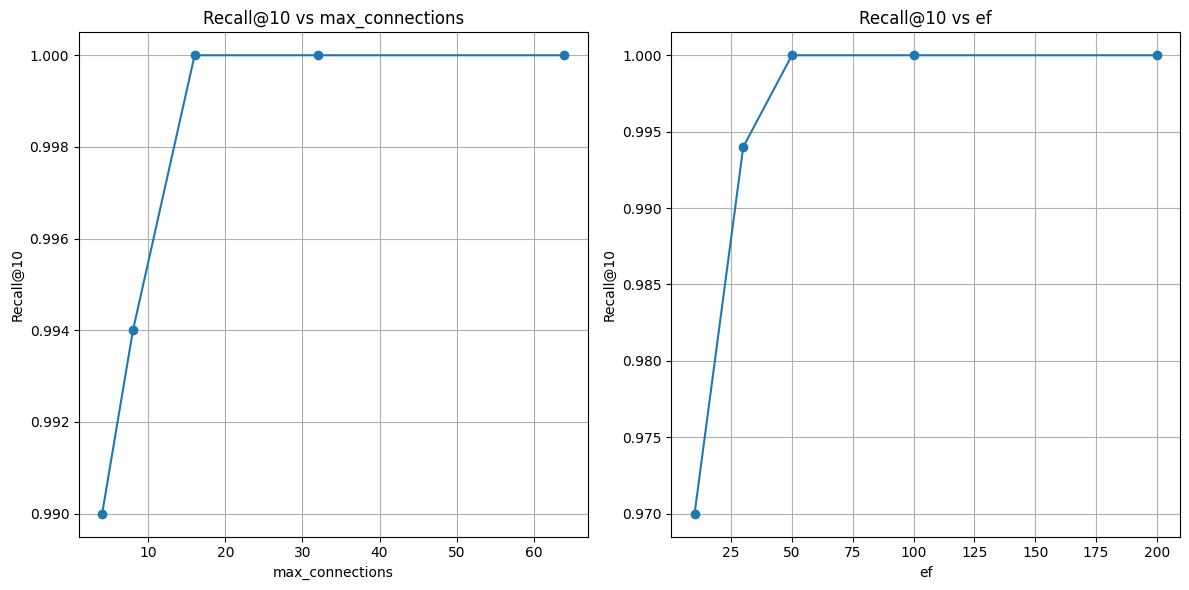

In [33]:
import matplotlib.pyplot as plt

# Vary max_connections
max_connections_values = [4, 8, 16, 32, 64]
recall_at_10_mc = []

for mc in max_connections_values:
    index = SupervisedHubsHNSW(base_norm, hub_levels=3, max_connections=mc, ef_construction=30)
    index.learn_hierarchy(ground_truth)
    index.build_index()
    metrics = index.evaluate(queries_norm, ground_truth)
    recall_at_10_mc.append(metrics['recall@10'])

# Vary ef
ef_values = [10, 30, 50, 100, 200]
recall_at_10_ef = []

for ef in ef_values:
    index = SupervisedHubsHNSW(base_norm, hub_levels=3, max_connections=8, ef_construction=ef)
    index.learn_hierarchy(ground_truth)
    index.build_index()
    metrics = index.evaluate(queries_norm, ground_truth)
    recall_at_10_ef.append(metrics['recall@10'])

# Plot results
plt.figure(figsize=(12, 6))

# Plot for max_connections
plt.subplot(1, 2, 1)
plt.plot(max_connections_values, recall_at_10_mc, marker='o')
plt.title('Recall@10 vs max_connections')
plt.xlabel('max_connections')
plt.ylabel('Recall@10')
plt.grid()

# Plot for ef
plt.subplot(1, 2, 2)
plt.plot(ef_values, recall_at_10_ef, marker='o')
plt.title('Recall@10 vs ef')
plt.xlabel('ef')
plt.ylabel('Recall@10')
plt.grid()

plt.tight_layout()
plt.show()